In [ ]:
from pathlib import Path
import sys, importlib
import pandas as pd
import mne

# ensure user set these at the notebook top
try:
    SUBJECT_ID, SESSION_DATE
except NameError:
    raise RuntimeError("Define SUBJECT_ID and SESSION_DATE at the top of the notebook before running this preflight cell.")

# repo helper import
try:
    from lib.io import build_subject_paths, DEFAULT_EEG_CHANNELS
except Exception as e:
    raise RuntimeError(f"Could not import lib.io helpers (run notebook from code/analysis): {e}")

# versions
def _ver(m):
    try:
        mod = importlib.import_module(m)
        return getattr(mod, "__version__", str(mod))
    except Exception:
        return None

print("Python:", sys.version.split()[0],
      "MNE:", _ver("mne"),
      "pandas:", _ver("pandas"),
      "numpy:", _ver("numpy"),
      "matplotlib:", _ver("matplotlib"))

# build paths
try:
    paths = build_subject_paths(SUBJECT_ID, SESSION_DATE, analysis_root=Path.cwd())
except Exception as e:
    raise RuntimeError(f"Unable to locate EDF/CSV: {e}")

edf_path = paths["edf_path"]
csv_path = paths["csv_path"]
out_dir = paths["out_dir"]
print(f"EDF: {edf_path}
CSV: {csv_path}
OUT: {out_dir}")

errors = []
warnings = []

# CSV checks
try:
    df = pd.read_csv(csv_path)
except Exception as e:
    raise RuntimeError(f"Could not read CSV: {e}")

if "stim_type" not in df.columns:
    errors.append("CSV missing 'stim_type' column.")
else:
    stypes = set(df["stim_type"].astype(str).unique())
    if "manual_sync_pulse" not in stypes:
        errors.append("CSV missing 'manual_sync_pulse' row (required for alignment).")
    if "sync_detection" not in stypes:
        errors.append("CSV missing 'sync_detection' row (required for EDF alignment).")

# EDF header checks (lightweight, no preload)
try:
    raw = mne.io.read_raw_edf(edf_path, preload=False, verbose="WARNING")
    sfreq = raw.info.get("sfreq", None)
    ch_names = raw.ch_names
    print(f"EDF sampling rate: {sfreq} Hz; channels found: {len(ch_names)}")
except Exception as e:
    raise RuntimeError(f"Error reading EDF header: {e}")

# EEG channel checks
requested = list(DEFAULT_EEG_CHANNELS)
available = [ch for ch in requested if ch in ch_names]
if not available:
    errors.append("No expected EEG channels found in EDF after channel renaming.")
else:
    missing = [c for c in requested if c not in ch_names]
    if missing:
        warnings.append(f"Missing some default EEG channels: {missing}")
    if "Pz" not in ch_names:
        warnings.append("Pz not present; P300 summary usually uses Pz (will fallback).")

# montage availability
try:
    _ = mne.channels.make_standard_montage("standard_1020")
except Exception:
    warnings.append("standard_1020 montage not available; topomap fallback may be less accurate.")

# output dir writable?
out_dir.mkdir(parents=True, exist_ok=True)
_test = out_dir / ".preflight_write_test"
try:
    with open(_test, "w") as fh:
        fh.write("ok")
    _test.unlink()
except Exception as e:
    errors.append(f"Cannot write to output directory {out_dir}: {e}")

# final verdict
if errors:
    print("PRECHECK FAILED:")
    for e in errors:
        print("ERROR:", e)
    raise RuntimeError("Preflight failed. Fix errors above before running the notebook.")
else:
    print("Preflight passed." + (f" Warnings: {len(warnings)}" if warnings else " No warnings."))
    for w in warnings:
        print("WARNING:", w)
    PREFLIGHT_OK = True


# Oddball — P300 ERP Analysis

Measures cortical response to rare auditory stimuli via Event-Related Potential (ERP).  
A healthy brain (or a brain with preserved awareness) generates a **P300** component ~300–600 ms
after a rare tone (2000 Hz), maximal over central-parietal electrodes (**Pz / Cz**).

| Condition | Tone | Rate |
| --- | --- | --- |
| Standard | 1000 Hz | 80 % of tones |
| Rare (deviant) | 2000 Hz | 20 % of tones |

A **positive finding** is a P300 amplitude significantly above the null distribution (p < 0.05 by
permutation test), maximal at Pz / Cz.

**Environment:** `stimulus_software/.venv` (MNE 1.11, scipy, pandas, matplotlib)

## 1. Configuration

In [6]:
import sys
from pathlib import Path

SUBJECT_ID = 'CON013'
SESSION_DATE = '2026-04-10'
EDF_FILENAME = f'{SUBJECT_ID}_clipped.EDF'
CSV_FILENAME = f'{SUBJECT_ID}_{SESSION_DATE}_stimulus_results.csv'

ANALYSIS_ROOT = Path.cwd().resolve()
if ANALYSIS_ROOT.name != 'analysis':
    ANALYSIS_ROOT = next(
        (parent for parent in [ANALYSIS_ROOT, *ANALYSIS_ROOT.parents]
         if parent.name == 'analysis' and (parent / 'notebooks').exists()),
        ANALYSIS_ROOT,
    )
if str(ANALYSIS_ROOT) not in sys.path:
    sys.path.insert(0, str(ANALYSIS_ROOT))

from lib.io import DEFAULT_EEG_CHANNELS, build_subject_paths

paths = build_subject_paths(
    SUBJECT_ID,
    SESSION_DATE,
    edf_filename=EDF_FILENAME,
    csv_filename=CSV_FILENAME,
    analysis_root=ANALYSIS_ROOT,
)
EDF_PATH = paths['edf_path']
CSV_PATH = paths['csv_path']
OUT_DIR = paths['out_dir']
EEG_CHANNELS = DEFAULT_EEG_CHANNELS.copy()
BAD_CHANNELS = []  # e.g. ['Fp1', 'T3']

print(f'Subject: {SUBJECT_ID}')
print(f'EDF: {EDF_PATH}')
print(f'CSV: {CSV_PATH}')
print(f'Output: {OUT_DIR}')

Subject: CON013
EDF: /Users/joey/Documents/EEG Project/code/stimulus_software/patient_data/edfs/CON013_clipped.EDF
CSV: /Users/joey/Documents/EEG Project/code/stimulus_software/patient_data/results/CON013_2026-04-10_stimulus_results.csv
Output: /Users/joey/Documents/EEG Project/code/analysis/results/CON013


## 2. Imports

In [7]:
import numpy as np
import pandas as pd
import mne
import matplotlib.pyplot as plt
from scipy import stats

from lib.io import align_stimulus_csv, load_raw_eeg_metadata
from lib.preprocessing import load_filtered_eeg

%matplotlib inline
mne.set_log_level('WARNING')
print(f'MNE {mne.__version__}')

MNE 1.11.0


## 3. Load EDF + Sync Alignment

In [ ]:
raw, sfreq, available_eeg = load_raw_eeg_metadata(
    EDF_PATH,
    eeg_channels=EEG_CHANNELS,
    bad_channels=BAD_CHANNELS,
    preload=False,
    verbose=False,
)
print(f'EEG channels ({len(available_eeg)}): {available_eeg}')
print(f'sfreq: {sfreq} Hz  |  duration: {raw.n_times/sfreq:.0f}s')

EEG channels (19): ['Fp1', 'Fp2', 'Fz', 'F3', 'F4', 'F7', 'F8', 'Cz', 'C3', 'C4', 'T3', 'T4', 'T5', 'T6', 'Pz', 'P3', 'P4', 'O1', 'O2']
sfreq: 512.0 Hz  |  duration: 4846s


/var/folders/0l/67m5yvqs3t5145ckdcz_pgs40000gn/T/ipykernel_47907/3666577757.py:2: RuntimeWarning: Omitted 5 annotation(s) that were outside data range.
  raw = mne.io.read_raw_edf(EDF_PATH, preload=False, verbose=False)
/var/folders/0l/67m5yvqs3t5145ckdcz_pgs40000gn/T/ipykernel_47907/3666577757.py:22: RuntimeWarning: The unit for channel(s) DC10, DC2, DC3, DC4, DC5, DC6, DC7, DC8, DC9 has changed from V to NA.
  raw.set_channel_types({ch: 'misc' for ch in dc_channels})


In [9]:
df, time_offset = align_stimulus_csv(CSV_PATH, sfreq=sfreq, n_times=raw.n_times)
print(f'time_offset = {time_offset:.4f} s')
print(f'sync rows: {(df['stim_type'] == 'sync_detection').sum()} detection, {(df['stim_type'] == 'manual_sync_pulse').sum()} manual pulse')

time_offset = -1828.7082 s
sync rows: 1 detection, 1 manual pulse


## 4. Preprocessing

In [10]:
# Load only the EEG channels we need, then filter for P300 analysis.
print(f'Loading {len(available_eeg)} EEG channels from {EDF_PATH.name}...')
raw_p300 = load_filtered_eeg(raw, available_eeg, l_freq=1, h_freq=30, verbose=False)
print('Preprocessing done.')

Loading 19 EEG channels from CON013_clipped.EDF...
Preprocessing done.


## 5. Epoch

In [11]:
odd_df = df[df['stim_type'] == 'oddball'].copy()
rare_df = odd_df[odd_df['notes'] == 'rare_tone']
std_df  = odd_df[odd_df['notes'] == 'standard_tone']

print(f'Oddball tones: {len(odd_df)} total  ({len(rare_df)} rare, {len(std_df)} standard)')

if len(rare_df) == 0:
    raise RuntimeError(
        'No per-beep oddball rows found. '
        'This subject may predate per-beep CSV logging. '
        'Check stim_type values with: df["stim_type"].value_counts()'
    )

intervals = np.diff(odd_df['edf_start'].sort_values().values)
print(f'Tone interval: mean={intervals.mean():.4f}s  std={intervals.std():.6f}s  (expected 1.0s)')

rare_events = np.column_stack([
    rare_df['start_sample'].values,
    np.zeros(len(rare_df), dtype=int),
    np.full(len(rare_df), 2, dtype=int)
])
std_events = np.column_stack([
    std_df['start_sample'].values,
    np.zeros(len(std_df), dtype=int),
    np.full(len(std_df), 1, dtype=int)
])
all_events = np.vstack([rare_events, std_events])
all_events = all_events[all_events[:, 0].argsort()]

epochs = mne.Epochs(
    raw_p300, events=all_events,
    event_id={'standard': 1, 'rare': 2},
    tmin=-0.2, tmax=0.8, baseline=(-0.2, 0),
    preload=True, verbose=False
)
print(f'Epochs: {len(epochs)}  ({len(epochs["rare"])} rare, {len(epochs["standard"])} standard)')

Oddball tones: 100 total  (14 rare, 86 standard)
Tone interval: mean=1.0181s  std=0.102310s  (expected 1.0s)
Epochs: 100  (14 rare, 86 standard)


## 6. Compute ERPs

In [12]:
evoked_rare = epochs['rare'].average()
evoked_std  = epochs['standard'].average()
diff_evoked = mne.combine_evoked([evoked_rare, evoked_std], weights=[1, -1])

P300_WIN = (0.300, 0.600)  # seconds
P300_CHANNELS = [ch for ch in ['Pz', 'Cz', 'P3', 'P4'] if ch in evoked_rare.ch_names]

# Mean amplitude in P300 window per channel
t = evoked_rare.times
win_mask = (t >= P300_WIN[0]) & (t <= P300_WIN[1])

print(f'P300 window ({int(P300_WIN[0]*1000)}–{int(P300_WIN[1]*1000)} ms) mean amplitude (Rare − Standard):')
for ch in P300_CHANNELS:
    idx = evoked_rare.ch_names.index(ch)
    amp = diff_evoked.data[idx][win_mask].mean() * 1e6
    print(f'  {ch}: {amp:+.2f} µV')

P300 window (300–600 ms) mean amplitude (Rare − Standard):
  Pz: +12.57 µV
  Cz: +5.48 µV
  P3: +11.53 µV
  P4: +12.51 µV


## 7. Permutation Test

Shuffle rare/standard trial labels 1000× to build a null distribution.
The observed statistic is mean (Rare − Standard) amplitude in the 300–600 ms window at Pz.

In [13]:
N_PERMS = 1000
P300_CH  = next((ch for ch in ['Pz', 'Cz'] if ch in epochs.ch_names), epochs.ch_names[0])

epochs_data = epochs.get_data()          # (n_trials, n_ch, n_times)
labels      = epochs.events[:, 2]        # 1=standard, 2=rare
t_ep        = epochs.times
win_mask_ep = (t_ep >= P300_WIN[0]) & (t_ep <= P300_WIN[1])
ch_idx      = epochs.ch_names.index(P300_CH)

def p300_amp(data, labs):
    rare_mean = data[labs == 2, ch_idx][:, win_mask_ep].mean()
    std_mean  = data[labs == 1, ch_idx][:, win_mask_ep].mean()
    return (rare_mean - std_mean) * 1e6   # µV

observed_amp = p300_amp(epochs_data, labels)

rng  = np.random.default_rng(42)
null = []
print(f'Running {N_PERMS} permutations on {P300_CH}...')
for _ in range(N_PERMS):
    null.append(p300_amp(epochs_data, rng.permutation(labels)))

null = np.array(null)
p_val = np.mean(null >= observed_amp)

print(f'\nResults at {P300_CH}:')
print(f'  Observed Rare−Std: {observed_amp:+.3f} µV')
print(f'  Null mean:         {null.mean():+.3f} µV  (95th pct: {np.percentile(null, 95):.3f} µV)')
print(f'  p-value:           {p_val:.4f}  {"✓ Significant" if p_val < 0.05 else "(not significant)"} (p < 0.05)')

Running 1000 permutations on Pz...

Results at Pz:
  Observed Rare−Std: +12.573 µV
  Null mean:         +0.099 µV  (95th pct: 10.241 µV)
  p-value:           0.0190  ✓ Significant (p < 0.05)


## 8. Plots

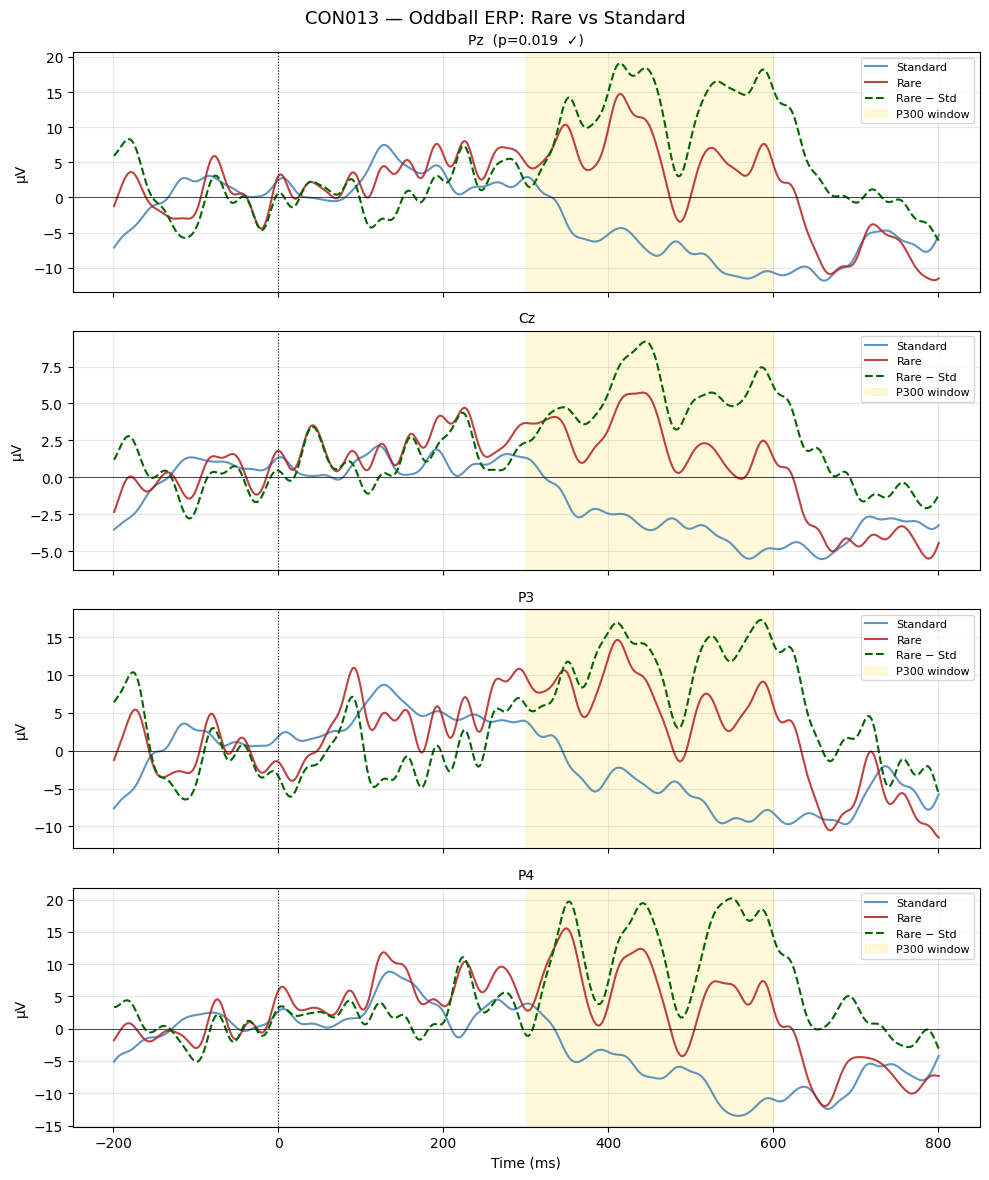

In [14]:
times_ms = evoked_rare.times * 1000

fig, axes = plt.subplots(len(P300_CHANNELS), 1,
                         figsize=(10, 3 * len(P300_CHANNELS)), sharex=True)
if len(P300_CHANNELS) == 1:
    axes = [axes]

for ax, ch_name in zip(axes, P300_CHANNELS):
    idx = evoked_rare.ch_names.index(ch_name)
    rare_uv = evoked_rare.data[idx] * 1e6
    std_uv  = evoked_std.data[idx]  * 1e6
    diff_uv = rare_uv - std_uv
    ax.plot(times_ms, std_uv,  color='steelblue', lw=1.5, label='Standard', alpha=0.85)
    ax.plot(times_ms, rare_uv, color='firebrick',  lw=1.5, label='Rare',     alpha=0.85)
    ax.plot(times_ms, diff_uv, color='darkgreen',  lw=1.5, ls='--', label='Rare − Std')
    ax.axvline(0, color='k', lw=0.8, ls=':')
    ax.axhline(0, color='k', lw=0.5)
    ax.axvspan(300, 600, color='gold', alpha=0.15, label='P300 window')
    if ch_name == P300_CH:
        p = p_val
        ax.set_title(f'{ch_name}  (p={p:.3f}{"  ✓" if p < 0.05 else ""})', fontsize=10)
    else:
        ax.set_title(ch_name, fontsize=10)
    ax.set_ylabel('µV')
    ax.legend(loc='upper right', fontsize=8)
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel('Time (ms)')
fig.suptitle(f'{SUBJECT_ID} — Oddball ERP: Rare vs Standard', fontsize=13)
plt.tight_layout()
plt.savefig(OUT_DIR / f'{SUBJECT_ID}_oddball_p300.png', dpi=150)
plt.show()

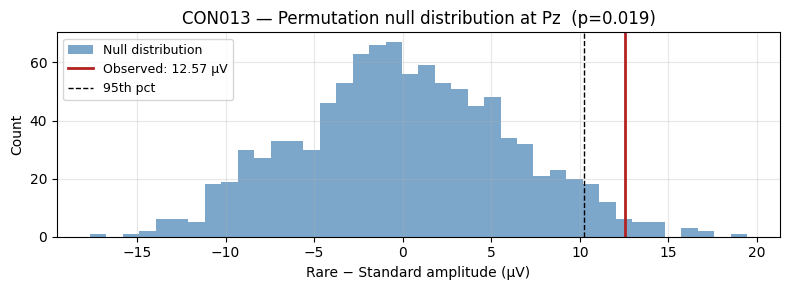

In [15]:
# Null distribution for primary P300 channel
fig, ax = plt.subplots(figsize=(8, 3))
ax.hist(null, bins=40, color='steelblue', alpha=0.7, label='Null distribution')
ax.axvline(observed_amp, color='firebrick', lw=2, label=f'Observed: {observed_amp:.2f} µV')
ax.axvline(np.percentile(null, 95), color='k', lw=1, ls='--', label='95th pct')
ax.set(xlabel='Rare − Standard amplitude (µV)', ylabel='Count',
       title=f'{SUBJECT_ID} — Permutation null distribution at {P300_CH}  (p={p_val:.3f})')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(OUT_DIR / f'{SUBJECT_ID}_p300_null.png', dpi=150)
plt.show()

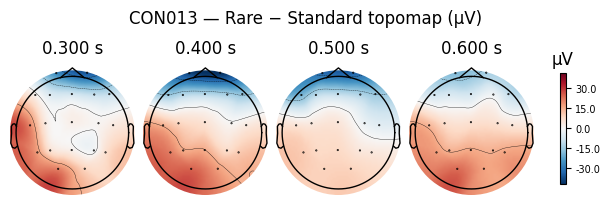

In [16]:
# Topomap of Rare − Standard at key latencies
montage = mne.channels.make_standard_montage('standard_1020')
diff_evoked.set_montage(montage, match_case=False, on_missing='warn')

fig = diff_evoked.plot_topomap(
    times=[0.3, 0.4, 0.5, 0.6], scalings=dict(eeg=1e6),
    show=False, cmap='RdBu_r'
)
fig.suptitle(f'{SUBJECT_ID} — Rare − Standard topomap (µV)', fontsize=12)
fig.savefig(OUT_DIR / f'{SUBJECT_ID}_p300_topomap.png', dpi=150)
plt.show()

## 9. Summary

**Positive finding:** P300 amplitude (Rare − Standard) significantly above null at 300–600 ms  
(p < 0.05 by permutation test), maximal at Pz / Cz.  
**Clinical interpretation:** Preserved cortical evaluation of deviant auditory stimuli — evidence of
passive attention / awareness.